<a href="https://colab.research.google.com/github/silvatria/PCVK_Ganjil_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mengubah tingkat kecerahan citra
Masukkan nilai kecerahan: 100


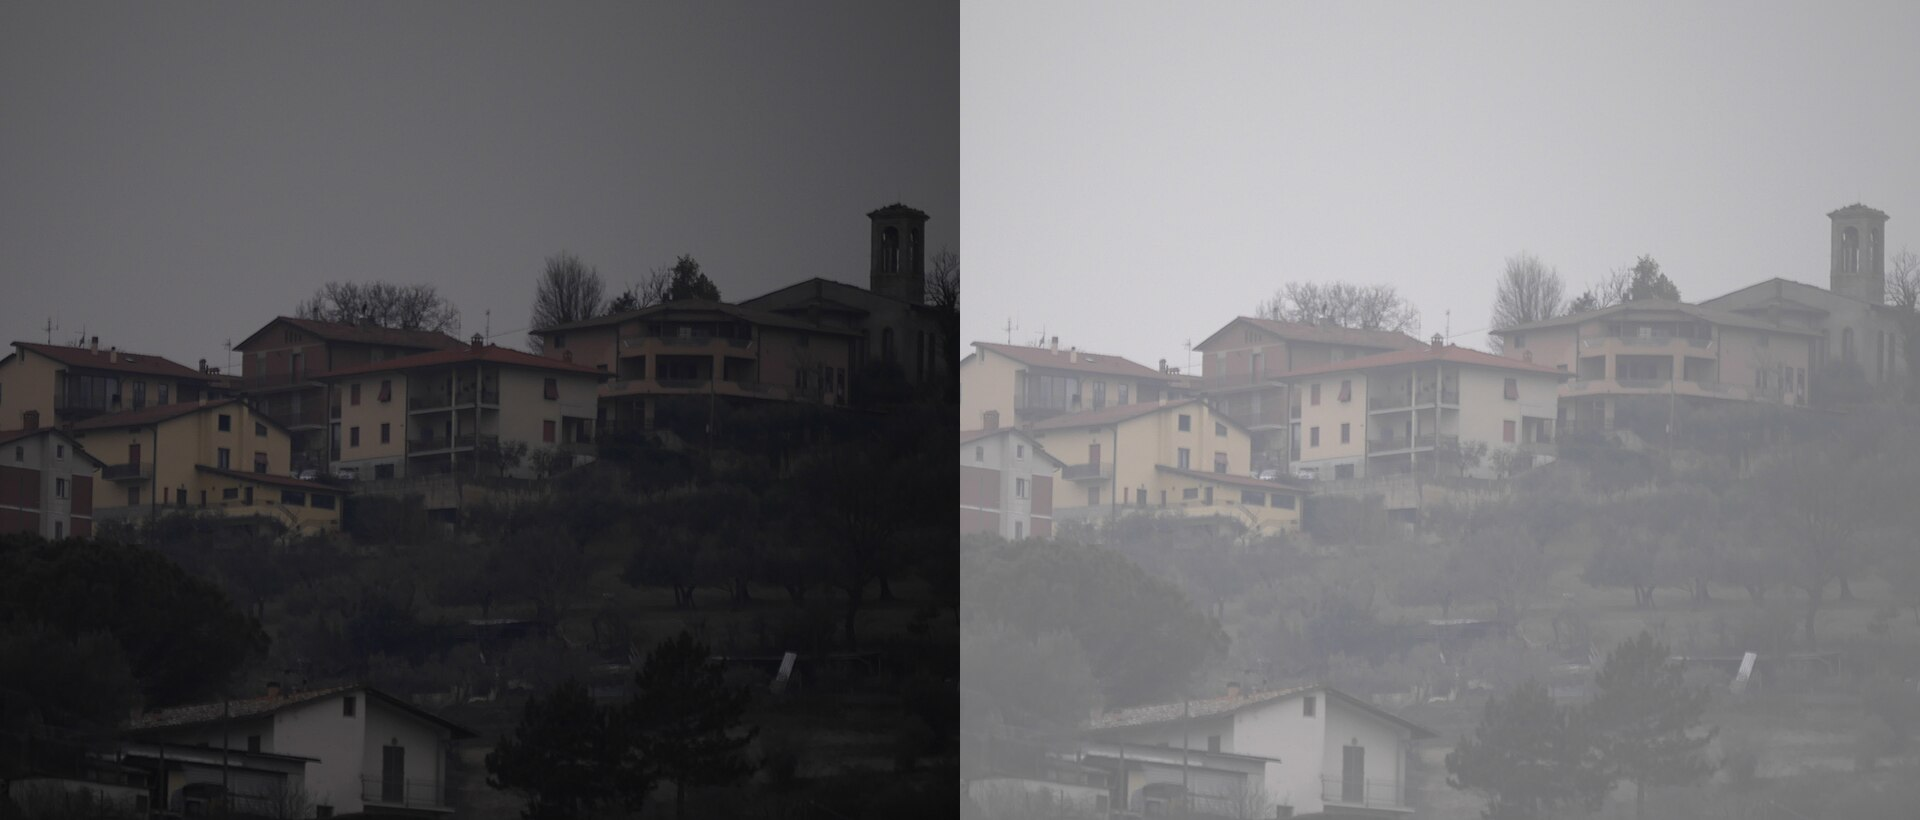

In [3]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Input nilai brightness dari pengguna
print('Mengubah tingkat kecerahan citra')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

# 3. Baca citra asli
original = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

# 4. Akses per piksel menggunakan looping 3 tingkat + np.clip (truncate)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

# 5. Gabungkan gambar asli dan hasil transformasi secara berdampingan
final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

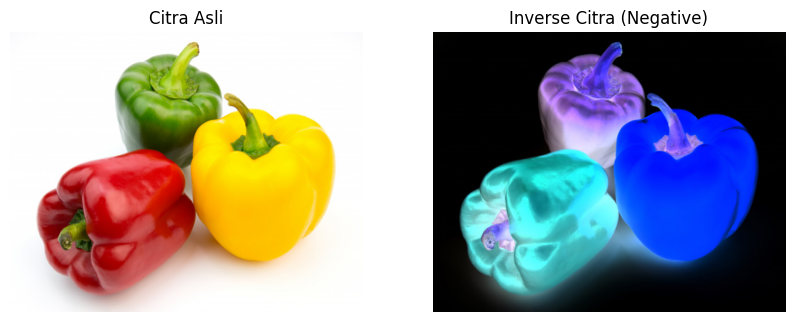

In [5]:
# 1. Inverse Citra
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_inv = 255 - img_rgb

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Citra Asli'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(img_inv), plt.title('Inverse Citra (Negative)'), plt.axis('off')
plt.show()

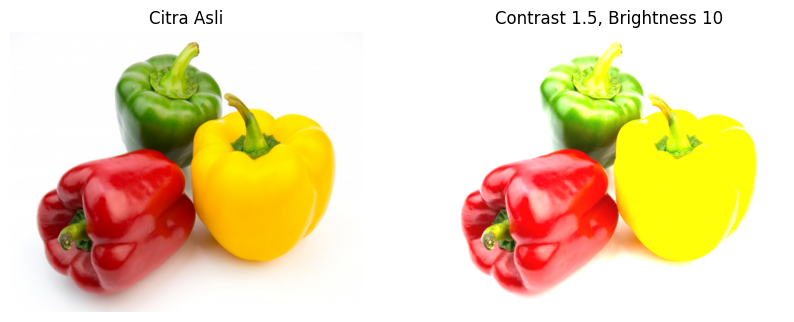

In [7]:
# 2. Transformasi Contrast & Brightness

import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

b = 10
contrast = 1.5
img_contrast = cv.convertScaleAbs(img_rgb, alpha=contrast, beta=b)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Citra Asli'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(img_contrast), plt.title(f'Contrast {contrast}, Brightness {b}'), plt.axis('off')
plt.show()

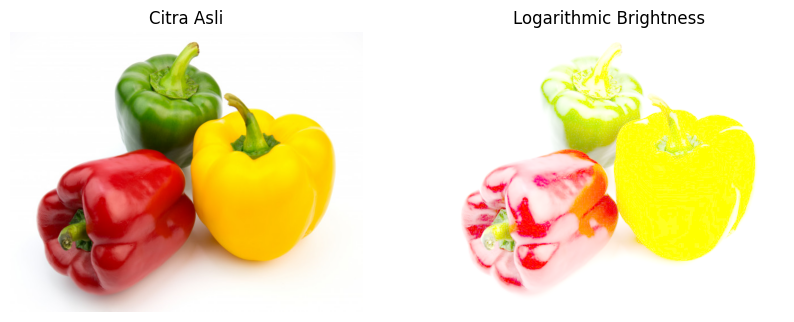

In [9]:
# 3. Transformasi Logarithmic Brightness

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB).astype(np.float32)

c = 50
img_log = c * np.log(1 + img_rgb)
img_log = np.uint8(np.clip(img_log, 0, 255))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)), plt.title('Citra Asli'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(img_log), plt.title('Logarithmic Brightness'), plt.axis('off')
plt.show()

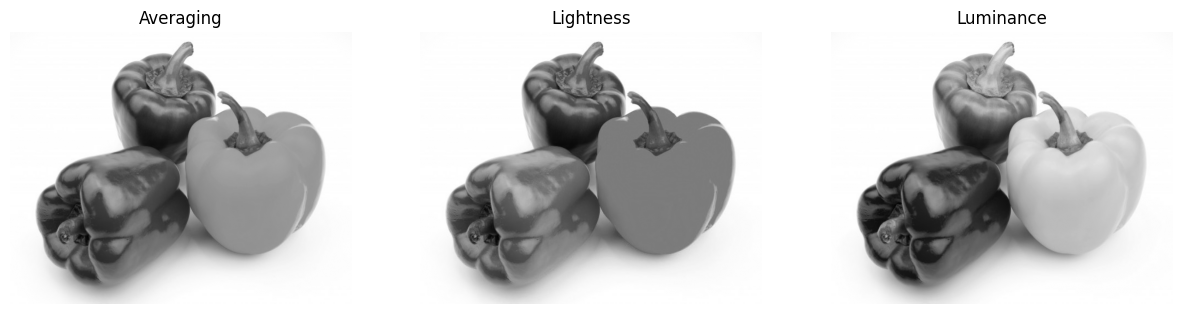

In [10]:
# 4. Grayscale (Averaging, Lightness, Luminance)
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB).astype(np.float32)
R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]

gray_avg = np.uint8((R + G + B) / 3)
gray_light = np.uint8((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2)
gray_lumi = np.uint8(0.21 * R + 0.72 * G + 0.07 * B)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(gray_avg, cmap='gray'), plt.title('Averaging'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(gray_light, cmap='gray'), plt.title('Lightness'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(gray_lumi, cmap='gray'), plt.title('Luminance'), plt.axis('off')
plt.show()

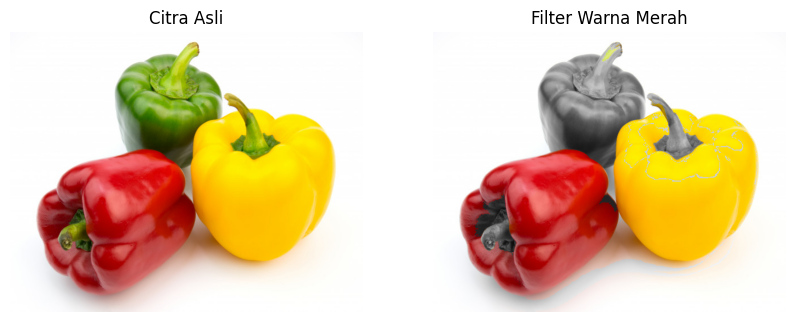

In [12]:
# 5. Seleksi Warna Tertentu (Warna Merah)
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
mask = (R > 120) & (R > G + 30) & (R > B + 30)

result = gray_3ch.copy()
result[mask] = img_rgb[mask]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Citra Asli'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(result), plt.title('Filter Warna Merah'), plt.axis('off')
plt.show()

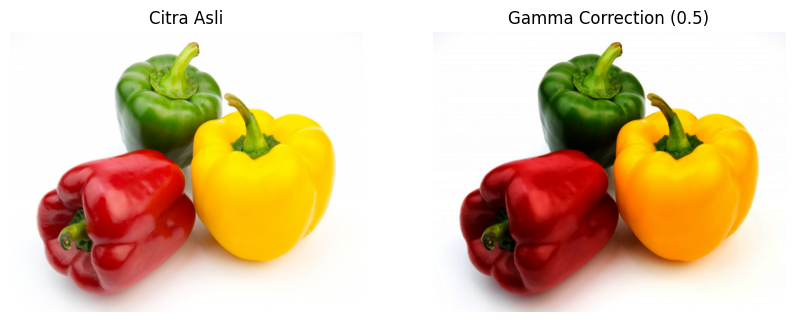

In [15]:
# 6. Gamma Correction
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

gamma = 0.5
inv_gamma = 1.0 / gamma
table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
img_gamma = cv.LUT(img_rgb, table)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Citra Asli'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(img_gamma), plt.title(f'Gamma Correction ({gamma})'), plt.axis('off')
plt.show()

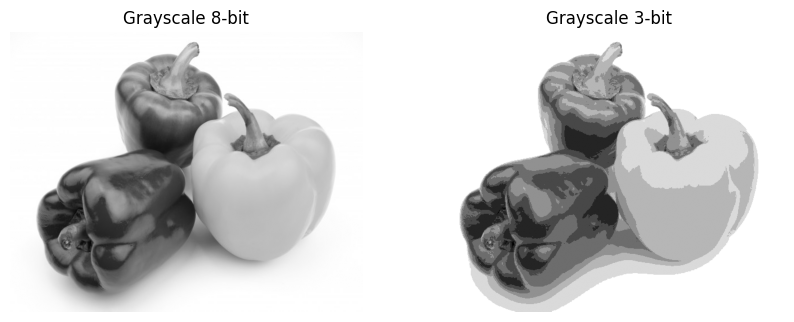

In [17]:
# 7. Simulasi Image Depth (Kuantisasi Bit)
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/peppers.jpg', cv.IMREAD_GRAYSCALE)
levels = 2 ** bit_depth

factor = 255 / (levels - 1)
img_depth = np.round(img / 255.0 * (levels - 1)) * factor
img_depth = img_depth.astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Grayscale 8-bit'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(img_depth, cmap='gray'), plt.title(f'Grayscale {bit_depth}-bit'), plt.axis('off')
plt.show()

In [21]:
# 8. Average Denoising & PSNR
import cv2 as cv
import numpy as np
import glob

def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100.0
    return 20 * np.log10(255.0 / np.sqrt(mse))

orig = cv.imread('ccgalaxy.jpg')
noise_paths = sorted(glob.glob('/content/drive/MyDrive/2C/PCVK/Images/noises/*.jpg'))

def get_averaged_image(n_count):
    subset = noise_paths[:n_count]
    imgs = [cv.imread(p).astype(np.float32) for p in subset]
    return np.mean(imgs, axis=0).astype(np.uint8)

if len(noise_paths) > 0:
    res_10 = get_averaged_image(10)
    print("PSNR (10 citra):", calculate_psnr(orig, res_10))

PSNR (10 citra): 19.735621628522026


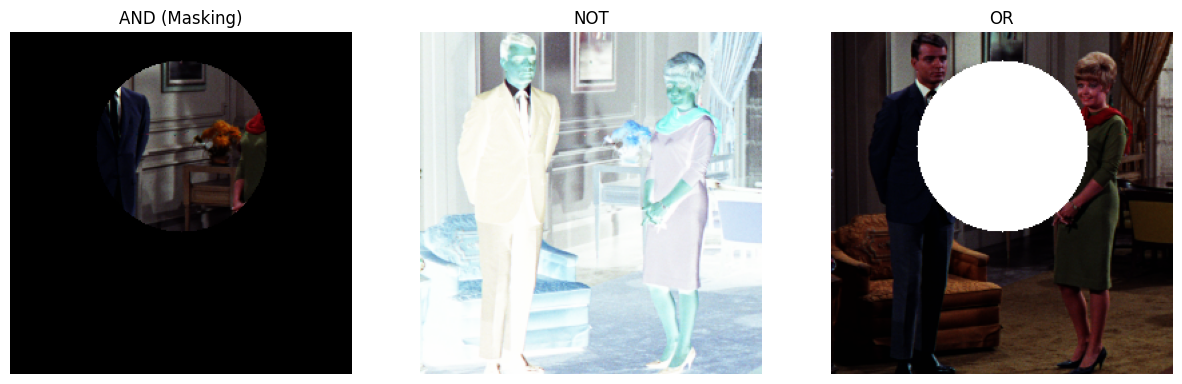

In [24]:
# 9. Image Masking (Operator Logika)
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_girl = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/couple.tiff')
h, w = img_girl.shape[:2]

mask = np.zeros((h, w, 3), dtype=np.uint8)
cv.circle(mask, (w//2, h//3), int(w//4), (255, 255, 255), -1)

res_and = cv.bitwise_and(img_girl, mask)
res_not = cv.bitwise_not(img_girl)
res_or = cv.bitwise_or(img_girl, mask)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(cv.cvtColor(res_and, cv.COLOR_BGR2RGB)), plt.title('AND (Masking)'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(cv.cvtColor(res_not, cv.COLOR_BGR2RGB)), plt.title('NOT'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(cv.cvtColor(res_or, cv.COLOR_BGR2RGB)), plt.title('OR'), plt.axis('off')
plt.show()

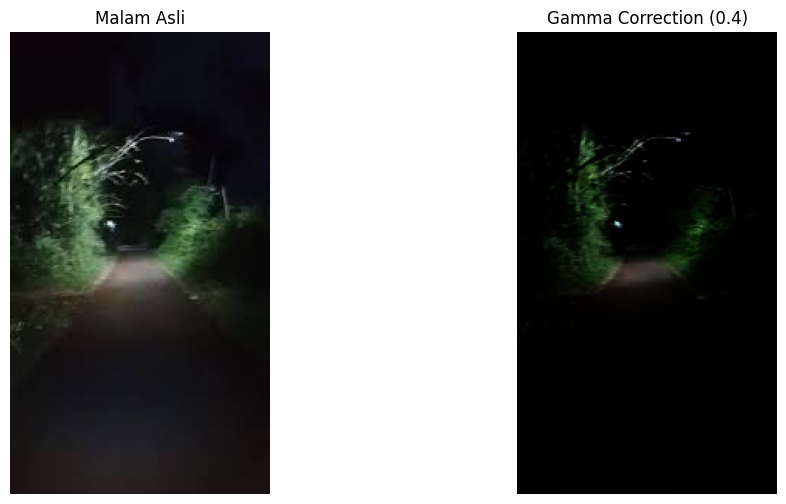

In [32]:
# 10. Studi Kasus Foto Malam Hari
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('malam.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

gamma = 0.4
inv_gamma = 1.0 / gamma
table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
img_gamma = cv.LUT(img_rgb, table)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Malam Asli'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(img_gamma), plt.title(f'Gamma Correction ({gamma})'), plt.axis('off')
plt.show()

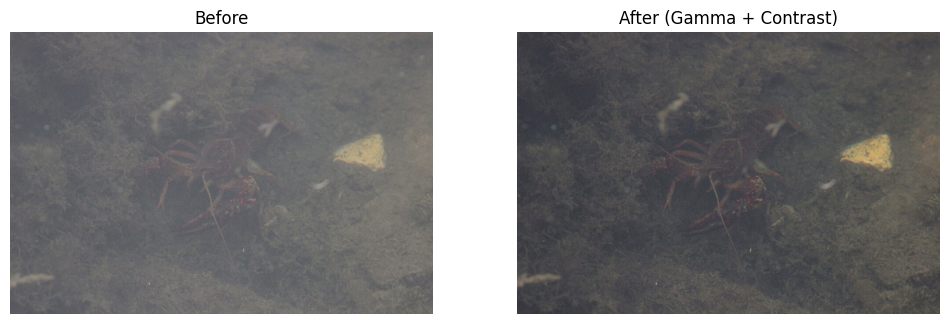

In [33]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/crayfish.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

gamma = 0.6
inv_gamma = 1.0 / gamma
table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
img_corrected = cv.LUT(img_rgb, table)

contrast = 1.3
img_final = cv.convertScaleAbs(img_corrected, alpha=contrast, beta=0)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Before'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(img_final), plt.title('After (Gamma + Contrast)'), plt.axis('off')
plt.show()